<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-04-02 19:52:04--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-results-public.sqlite’

survey-results-publ 100%[===================>] 201.62M  44.9MB/s    in 4.5s    

2026-04-02 19:52:11 (44.9 MB/s) - ‘survey-results-public.sqlite’ saved [211415040/211415040]



#### 2. Connect to the Database


**Install the needed libraries**


In [2]:
!pip install pandas

In [3]:
!pip install matplotlib
!pip install seaborn

In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')


## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [5]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


#### Demo 2: List All Tables


In [6]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Demo 3: Group Data by Age


In [7]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


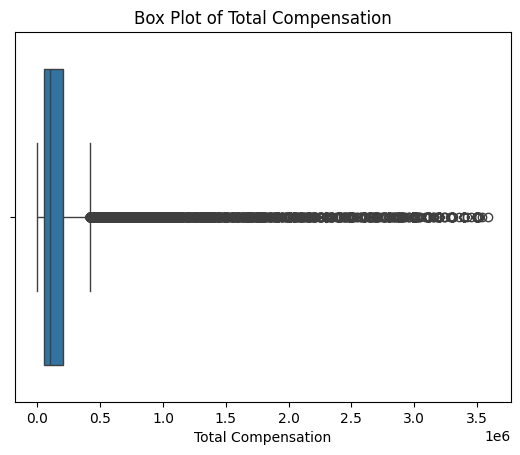

In [14]:
QUERY = "SELECT CompTotal FROM main"
df = pd.read_sql_query(QUERY, conn)
comp_df = df[df['CompTotal'] < df['CompTotal'].quantile(0.95)]

sns.boxplot(x=comp_df['CompTotal'])
plt.title('Box Plot of Total Compensation')
plt.xlabel('Total Compensation')
plt.show()

**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


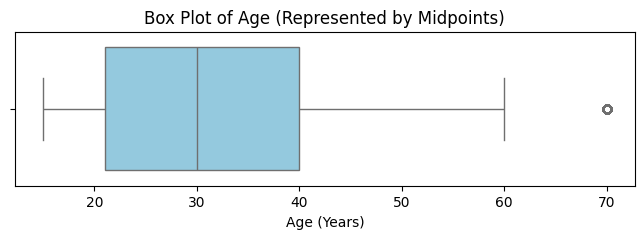

In [15]:
QUERY = "SELECT Age FROM main"
df = pd.read_sql_query(QUERY, conn)

age_map = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}

df['Age_Numeric'] = df['Age'].map(age_map)

plt.figure(figsize=(8, 2))
sns.boxplot(x=df['Age_Numeric'], color='skyblue')
plt.title('Box Plot of Age (Represented by Midpoints)')
plt.xlabel('Age (Years)')
plt.show()

### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


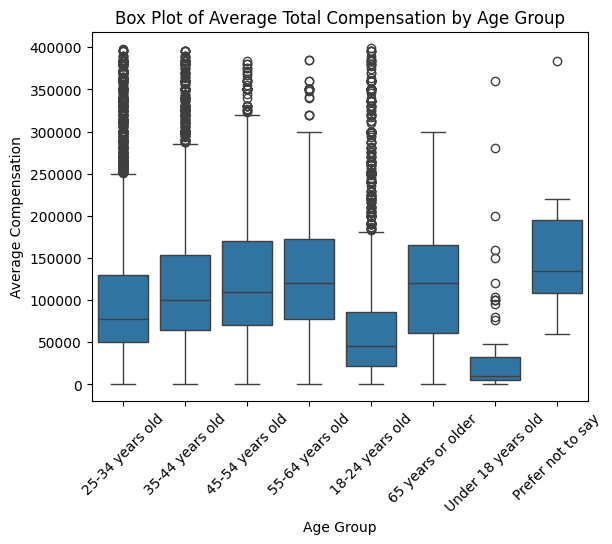

In [28]:
QUERY = "SELECT Age, CompTotal FROM main"
df = pd.read_sql_query(QUERY, conn)
comp_df = df[df['CompTotal'] < df['CompTotal'].quantile(0.80)]

sns.boxplot(x='Age', y='CompTotal', data=comp_df)

plt.title('Box Plot of Average Total Compensation by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Compensation')
plt.xticks(rotation=45) # Rotates labels for better readability
plt.show()

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


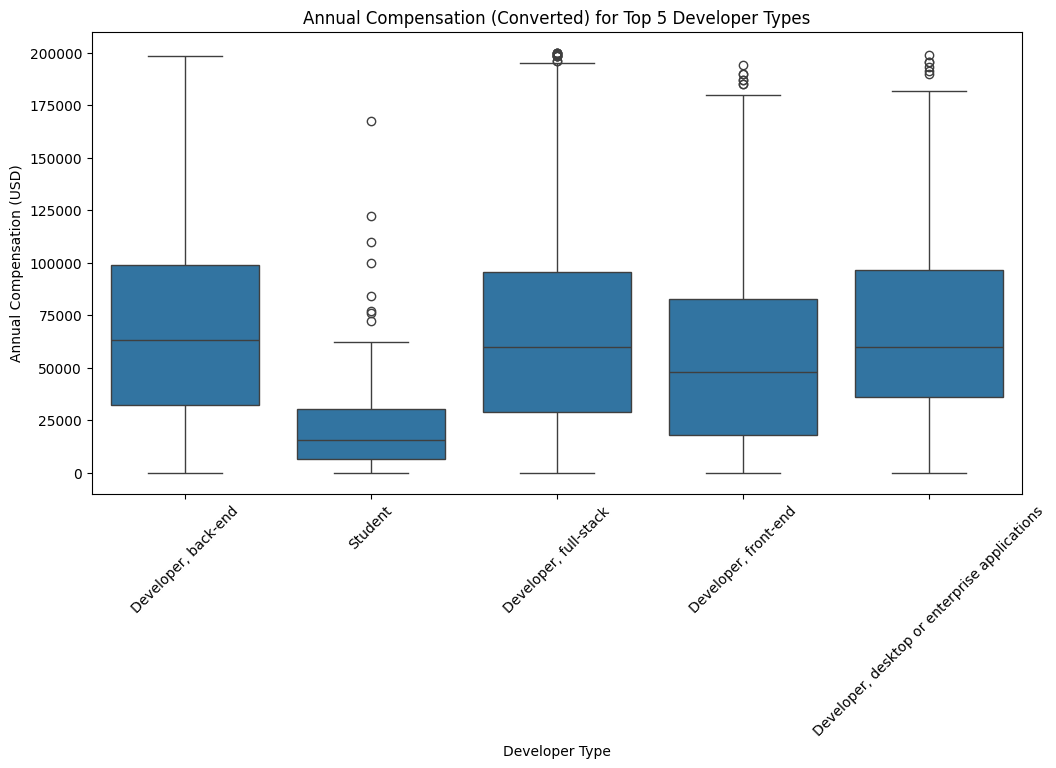

In [37]:
# 1. Identify the Top 5 Developer Types by frequency
QUERY = """
SELECT DevType, ConvertedCompYearly FROM main WHERE DevType IN
(SELECT DevType FROM main 
GROUP BY DevType 
ORDER BY Count(*) DESC 
LIMIT 6)
"""

df_plot = pd.read_sql_query(QUERY, conn)

# 3. Handle Outliers (Optional but recommended for compensation data)
# Filtering to the 95th percentile helps keep the "boxes" visible
df_filtered = df_plot[df_plot['ConvertedCompYearly'] < df_plot['ConvertedCompYearly'].quantile(0.95)]

# 4. Create the Box Plot
plt.figure(figsize=(12, 6))
sns.boxplot(x='DevType', y='ConvertedCompYearly', data=df_filtered)

plt.title('Annual Compensation (Converted) for Top 5 Developer Types')
plt.xlabel('Developer Type')
plt.ylabel('Annual Compensation (USD)')
plt.xticks(rotation=45)
plt.show()

**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


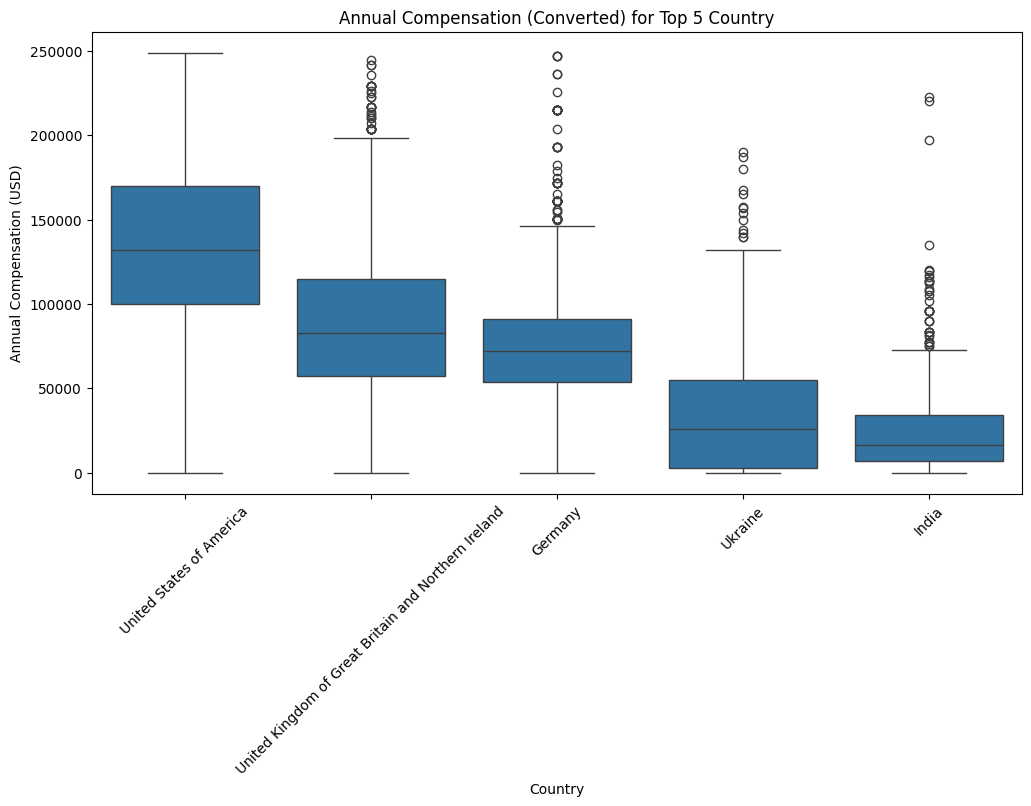

In [36]:
# 1. Identify the Top 5 Country by frequency
QUERY = """
SELECT Country, ConvertedCompYearly FROM main WHERE Country IN
(SELECT Country FROM main 
GROUP BY Country 
ORDER BY Count(*) DESC 
LIMIT 6)
"""

df_plot = pd.read_sql_query(QUERY, conn)

# 3. Handle Outliers (Optional but recommended for compensation data)
# Filtering to the 95th percentile helps keep the "boxes" visible
df_filtered = df_plot[df_plot['ConvertedCompYearly'] < df_plot['ConvertedCompYearly'].quantile(0.95)]

# 4. Create the Box Plot
plt.figure(figsize=(12, 6))
sns.boxplot(x='Country', y='ConvertedCompYearly', data=df_filtered)

plt.title('Annual Compensation (Converted) for Top 5 Country')
plt.xlabel('Country')
plt.ylabel('Annual Compensation (USD)')
plt.xticks(rotation=45)
plt.show()

### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


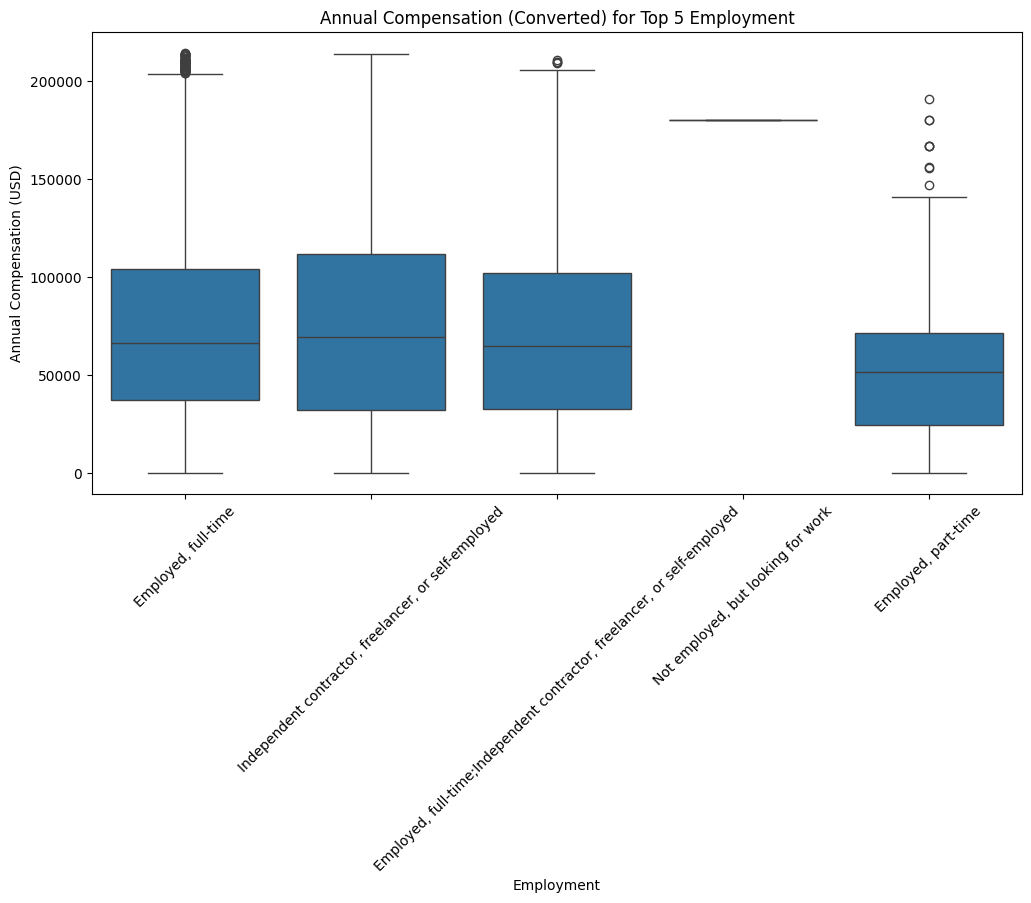

In [38]:
QUERY = """
SELECT Employment, ConvertedCompYearly FROM main WHERE Employment IN
(SELECT Employment FROM main 
GROUP BY Employment 
ORDER BY Count(*) DESC 
LIMIT 6)
"""

df_plot = pd.read_sql_query(QUERY, conn)

# Filtering to the 95th percentile helps keep the "boxes" visible
df_filtered = df_plot[df_plot['ConvertedCompYearly'] < df_plot['ConvertedCompYearly'].quantile(0.95)]

plt.figure(figsize=(12, 6))
sns.boxplot(x='Employment', y='ConvertedCompYearly', data=df_filtered)

plt.title('Annual Compensation (Converted) for Top 5 Employment')
plt.xlabel('Employment')
plt.ylabel('Annual Compensation (USD)')
plt.xticks(rotation=45)
plt.show()

### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [39]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
